In [ ]:
# HyperTools setup: use 1.1 or newer; retain a current local checkout.
import importlib.util
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version
from pathlib import Path
try:
    _hypertools_version = Version(version('hypertools'))
except PackageNotFoundError:
    _hypertools_version = Version('0')
if _hypertools_version < Version('1.1.0'):
    _spec = importlib.util.find_spec('hypertools')
    if _spec and _spec.origin and (Path(_spec.origin).resolve().parents[1] / '.git').exists():
        raise RuntimeError('Select a HyperTools 1.1 checkout/kernel before running this tutorial; the installer will not replace your checkout.')
    %pip install -q "hypertools[interactive]>=1.1.0"
else:
    print('Keeping HyperTools', _hypertools_version, 'in this kernel. Optional extras are loaded when requested.')


In [ ]:
import importlib.util
# This tutorial also uses convokit (not a HyperTools dep) for the Reddit
# corpus; self-install it so a top-to-bottom run works headlessly too.
if importlib.util.find_spec('convokit') is None:
    %pip install -q convokit


# Reddit thread trajectories: one stroke per utterance, one color per speaker

Conversations move.  A discussion drifts from topic to topic, doubles back on
itself, and takes sharp turns when a new speaker chimes in.  In this tutorial
we'll make that motion visible: we'll take a real Reddit conversation, embed a
sliding window of sentences within each utterance using a sentence-embedding
model, and use HyperTools to draw the conversation as a sequence of utterance
trajectories through meaning space -- colored by who is speaking, and animated
so that each utterance draws itself into the scene, one at a time.

This tutorial uses `convokit` for the Reddit corpus; it is not a HyperTools
dependency, so the install cell above fetches it (`%pip install convokit`).
The sentence-embedding model runs through HyperTools' `[text]` extra
(sentence-transformers), which HyperTools installs on demand the first time
an embedding is requested.

(The [conversation-shape tutorial](conversation_shape.ipynb) is the
companion piece: it follows each *speaker's* path through a scripted
conversation with `order='serial'`; this one follows a real Reddit thread
utterance by utterance with `animate='serial'`.)

In [2]:
%matplotlib inline
import os

import random

from convokit import Corpus, download

import hypertools as hyp


## Downloading a corpus of Reddit conversations

[ConvoKit](https://convokit.cornell.edu) provides easy access to dozens of
conversational datasets.  We'll use the `reddit-corpus-small` corpus, which
contains posts and comment threads sampled from 100 highly active
subreddits.

In [3]:
corpus = Corpus(filename=download('reddit-corpus-small'))
corpus.meta

Dataset already exists at ~/.convokit/saved-corpora/reddit-corpus-small


ConvoKitMeta({'subreddit': 'reddit-corpus-small', 'num_posts': 8286, 'num_comments': 288846, 'num_user': 119889})

## Choosing a conversation

We'll pick a conversation at random (seeded for reproducibility) from among
the conversations with at least 10 "usable" utterances -- i.e., utterances
whose text hasn't been deleted or removed.  Since we're about to trace how
individual utterances move through meaning space, we also require a
conversation where people actually say something: most utterances should
contain several sentences (at least 60% with 2+ sentence windows), with at
most 40 utterances so the animation stays legible.  Utterances are taken in
chronological order, treating the comment thread as one unfolding
conversation.

In [4]:
MIN_UTTERANCES = 10
MAX_UTTERANCES = 40
SENTENCE_WINDOW = 3

def usable_utterances(conversation):
    """Chronologically-ordered utterances with non-empty, non-deleted text."""
    utterances = conversation.get_chronological_utterance_list()
    return [u for u in utterances
            if u.text and u.text.strip()
            and u.text.strip() not in ('[deleted]', '[removed]')]

def count_windows(text):
    """Number of sliding sentence-windows `hyp.text_windows` yields for `text`."""
    return len(hyp.text_windows(text, size=SENTENCE_WINDOW, step=1, unit='sentences'))

def substantial(conversation):
    utterances = usable_utterances(conversation)
    if not MIN_UTTERANCES <= len(utterances) <= MAX_UTTERANCES:
        return False
    if len(set(u.speaker.id for u in utterances)) < 2:
        return False
    multi = sum(1 for u in utterances if count_windows(u.text.strip()) >= 2)
    return multi / len(utterances) >= 0.6

candidates = [c for c in corpus.iter_conversations() if substantial(c)]
print(f'qualifying conversations: {len(candidates)}')

random.seed(25)
conversation = random.choice(candidates)
utterances = usable_utterances(conversation)
speakers = [u.speaker.id for u in utterances]
texts = [u.text.strip() for u in utterances]

print(f"\ntitle: {conversation.meta['title']}")
print(f"subreddit: r/{conversation.meta['subreddit']}")
print(f'utterances: {len(utterances)}; speakers: {len(set(speakers))}')
print('\nopening exchange:')
for u in utterances[:4]:
    print(f'  [{u.speaker.id}] {u.text.strip()[:90]}...')

qualifying conversations: 244

title: Why don’t more cameras have dual native iso? Also, why couldn’t we have a sensor that captures images using multiple ISOs at once?
subreddit: r/photography
utterances: 10; speakers: 5

opening exchange:
  [CCtenor] We have all seen how good recent sensors are, capable of capturing almost 15 stops of dyna...
  [implode573] ISO doesn't work how you think it does. That "native ISO" you're looking for is called SNR...
  [CCtenor] Yes, and the “native iso” is the setting at which a camera is not applying any gain to the...
  [CCtenor] &gt; The SNR is there because heat and transferring. Many camera systems now work around t...


## Windowing each utterance with a sliding sentence window

To turn each utterance into its own mini-trajectory, we slide a window of 3
consecutive *sentences* along the text of that utterance with
`hyp.text_windows(utterance, size=3, step=1, unit='sentences')`, which
concatenates the sentences inside each window.  Because the windows never cross utterance
boundaries, every utterance becomes a *truly separate* trajectory: utterances
never share points.

Utterances with fewer than 3 sentences get a single window containing the
whole utterance.  A single-window utterance is a single point, so below we
plot with the `'.-'` format -- dots at every embedding window plus connecting
lines -- which keeps those utterances visible as single dots.

The embedding itself happens inside `hyp.plot`: passing
`vectorizer='all-MiniLM-L6-v2'` hands every
window to
[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
a compact sentence-BERT model (for an embedding vectorizer HyperTools skips
the topic-model stage it applies to count-based text by default).  The nesting of the input -- a
list (per utterance) of lists of window texts -- is the grouping, so no
re-splitting of an embedding matrix is needed.

In [5]:
utterance_windows = [  # list (per utterance) of lists of window texts
    hyp.text_windows(text, size=SENTENCE_WINDOW, step=1, unit='sentences')
    for text in texts]

print(f'{len(utterance_windows)} utterance trajectories; '
      f'windows per utterance: {[len(w) for w in utterance_windows]}')


10 utterance trajectories; windows per utterance: [31, 1, 1, 13, 11, 3, 6, 1, 17, 12]


## One color per speaker

Every speaker gets one fixed color, and every utterance is drawn in its
speaker's color -- so in a two-person conversation exactly two colors
alternate, and in this thread the colors repeat whenever a speaker takes
another turn.

We get that by handing `hyp.plot` a categorical `hue`: one speaker label per
DATASET (utterance) rather than one per row -- `hyp.plot` broadcasts a
per-dataset `hue=` entry across every row of that dataset, so `hue=speakers`
replaces building a per-window list by hand. HyperTools assigns each distinct
label its own color from seaborn's `hls` palette, in order of first
appearance, and `legend=True` gives each speaker exactly one legend entry.

In [6]:
# one hue label per DATASET (utterance); hyp.plot broadcasts it across every
# row of that utterance's own trajectory -- hue=speakers, rather than
# hue=[[speaker] * len(w) for speaker, w in zip(speakers, utterance_windows)]
speaker_names = sorted(set(speakers), key=speakers.index)
print(f'{len(speaker_names)} speakers -> {len(speaker_names)} colors '
      f'across {len(utterance_windows)} utterances')

5 speakers -> 5 colors across 10 utterances


## The static shape of the conversation

HyperTools embeds each window and reduces the 384-dimensional embeddings to 3D and draws each
utterance as its own stroke, colored by its speaker.  The utterances are
*not* connected to each other -- each one is a separate trajectory through
meaning space.

`hyp.plot(utterance_windows, '.-', vectorizer=..., ...)` embeds every window,
stacks the embeddings into one matrix, fits a *single* shared `IncrementalPCA` (the default `reduce`)
down to `ndims=3`, then splits the reduced rows back into per-utterance
trajectories.  Because one model is fit across all of them, positions are
directly comparable across utterances and across speakers.  The `'.-'` format
draws a dot at every embedding window plus lines connecting consecutive
windows *within* an utterance.

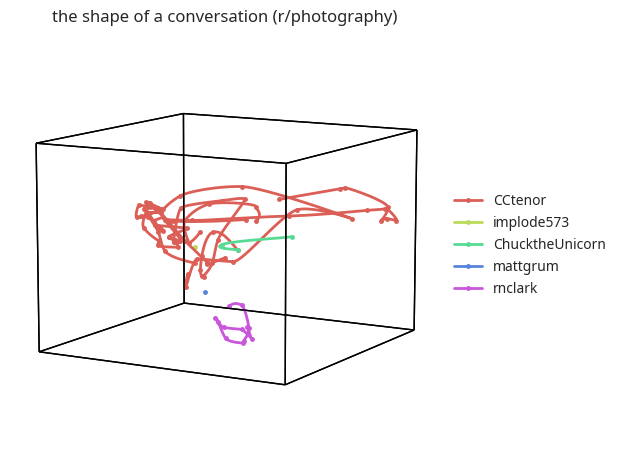

In [7]:
fig = hyp.plot(utterance_windows, '.-', vectorizer='all-MiniLM-L6-v2',
               hue=speakers, legend=True,
               linewidth=2, markersize=5, show=False,
               title=f"the shape of a conversation (r/{conversation.meta['subreddit']})")
fig

Each color is one speaker; each stroke is one utterance (utterances with a
single embedding window appear as a single dot).  Longer, winding
strokes are utterances that themselves wander across several ideas; compact
strokes are short, single-thought comments.

## Watching the conversation unfold

Now for the fun part.  HyperTools' `animate='serial'` mode plays the datasets
back *in list order*: the first utterance grows point-by-point into place;
then the second grows while the first stays fixed; and so on until the whole
conversation has assembled itself -- all while the camera slowly makes one
orbit of the scene over the 20-second animation.  Utterances are never
connected to each other; each new stroke simply appears where the
conversation went next.

`zoom=1.5` pulls the camera in so the trajectories fill more of the frame,
and `frame_rate=15` sets the rendered frames per second -- so `duration=20` x
`frame_rate=15` is 300 rendered frames, spread over the camera's
`rotations=1` single orbit.

`save_path='conversation_trajectories.mp4'` encodes the video directly
(`.mp4` uses FFmpeg; a `.gif` needs no external tool at all), and the
markdown cell below embeds it.

In [8]:
anim = hyp.plot(utterance_windows, '.-', vectorizer='all-MiniLM-L6-v2',
                hue=speakers, markersize=5,
                animate='serial', duration=20, rotations=1, frame_rate=15,
                zoom=1.5, linewidth=2,
                save_path='conversation_trajectories.mp4', show=False)

print(f"video: {os.path.getsize('conversation_trajectories.mp4')/1e6:0.1f} MB")

# Colab serves output frames separately from kernel files; embed movie bytes.
try:
    import google.colab
except ImportError:
    pass  # Local Jupyter/Sphinx uses the relative video below.
else:
    from IPython.display import Video, display
    display(Video('conversation_trajectories.mp4', embed=True))


video: 0.9 MB


<video controls loop muted autoplay playsinline src="conversation_trajectories.mp4" title="A Reddit thread assembling itself, one utterance at a time" style="max-width: 100%"></video>

[Download the clip](conversation_trajectories.mp4)

## Next steps

Try a longer conversation (raise `MIN_UTTERANCES`), a different sentence
window length, or another ConvoKit corpus entirely (`movie-corpus`,
`supreme-court-arguments`, ...).  You could also compare *several*
conversations at once by passing multiple trajectories to `hyp.plot`, or use
`hyp.align` to map different conversations into a shared space.